In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# import from shimnet
import sys, os
sys.path.append(os.path.abspath("../src")) # add src to path
from generators import get_datapipe

In [21]:
config_path = "../configs/shimnet_600.yaml"
config = OmegaConf.load(config_path)
data_config = config.data
print(OmegaConf.to_yaml(data_config))


response_functions_files:
- data/scrf_81_600MHz.pt
atom_groups_data_file: data/multiplets_10000_parsed.txt
response_function_stretch_min: 1.0
response_function_stretch_max: 1.0
response_function_noise: 0.0
multiplicity_j1_min: 0.0
multiplicity_j1_max: 15
multiplicity_j2_min: 0.0
multiplicity_j2_max: 15
number_of_signals_min: 2
number_of_signals_max: 5
thf_min: 0.5
thf_max: 2
relative_height_min: 0.5
relative_height_max: 4
frq_step: 0.30048



In [22]:
# modify paths in data config if we don't run from the root directory
print("original response function file:", data_config.response_functions_files[0])
data_config.response_functions_files[0] = os.path.join("..", data_config.response_functions_files[0])
print("modified response function file:", data_config.response_functions_files[0])
print()
print("original atom_groups_data_file:", data_config.atom_groups_data_file)
data_config.atom_groups_data_file = os.path.join("..", data_config.atom_groups_data_file)
print("modified atom_groups_data_file:", data_config.atom_groups_data_file)

original response function file: data/scrf_81_600MHz.pt
modified response function file: ../data/scrf_81_600MHz.pt

original atom_groups_data_file: data/multiplets_10000_parsed.txt
modified atom_groups_data_file: ../data/multiplets_10000_parsed.txt


In [36]:
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step

In [23]:
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)

/home/mbuk/miniconda3/envs/shimnetcpu/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


In [24]:
batch = next(iter(data_pipe))
print(batch.keys())

dict_keys(['theoretical_spectrum', 'noised_spectrum', 'disturbed_spectrum', 'response_function', 'theoretical_spectrum_data'])


In [32]:
batch["response_function"].shape

torch.Size([10, 1, 1, 81])

In [41]:
spectrum_data

[{'tff_lin': tensor([-193.7640, -192.9484]),
  'thf_lin': tensor([0.8995, 0.8995]),
  'twf_lin': tensor([1.0404, 1.0404]),
  'trf_lin': tensor([0.9476, 0.9476]),
  'tff_relative': tensor([379.1519, 381.8660])},
 {'tff_lin': tensor([-19.7580, -14.3465]),
  'thf_lin': tensor([0.6271, 0.6271]),
  'twf_lin': tensor([0.9619, 0.9619]),
  'trf_lin': tensor([0.5394, 0.5394]),
  'tff_relative': tensor([958.2451, 976.2546])},
 {'tff_lin': tensor([-131.9634, -131.2517, -130.5400, -129.8283, -124.5091, -123.7974,
          -123.0857, -122.3740, -117.0548, -116.3431, -115.6314, -114.9197]),
  'thf_lin': tensor([0.0174, 0.0521, 0.0521, 0.0174, 0.0348, 0.1043, 0.1043, 0.0348, 0.0174,
          0.0521, 0.0521, 0.0174]),
  'twf_lin': tensor([0.7376, 0.7376, 0.7376, 0.7376, 0.7376, 0.7376, 0.7376, 0.7376, 0.7376,
          0.7376, 0.7376, 0.7376]),
  'trf_lin': tensor([0.4154, 0.4154, 0.4154, 0.4154, 0.4154, 0.4154, 0.4154, 0.4154, 0.4154,
          0.4154, 0.4154, 0.4154]),
  'tff_relative': tensor([58

In [44]:
multiplet_data["tff_lin"]

tensor([-193.7640, -192.9484])

In [45]:
multiplet_data["thf_lin"]

tensor([0.8995, 0.8995])

In [51]:
multiplet_data["tff_lin"].mean()

tensor(130.2520)

In [52]:
def get_multiplet_info(multiplet_data):
    info_string = f"# peaks: {len(multiplet_data['tff_lin'])}"
    info_string += f"\nwidth: {multiplet_data['twf_lin'][0].item():.3f} Hz"
    info_string += f"\nGaussian fraction: {multiplet_data['trf_lin'][0].item():.3f}"
    return info_string

In [54]:
print(get_multiplet_info(batch['theoretical_spectrum_data'][5][0]))

# peaks: 2
width: 0.454 Hz
Gaussian fraction: 0.476


Text(0.5, 1.0, 'response function')

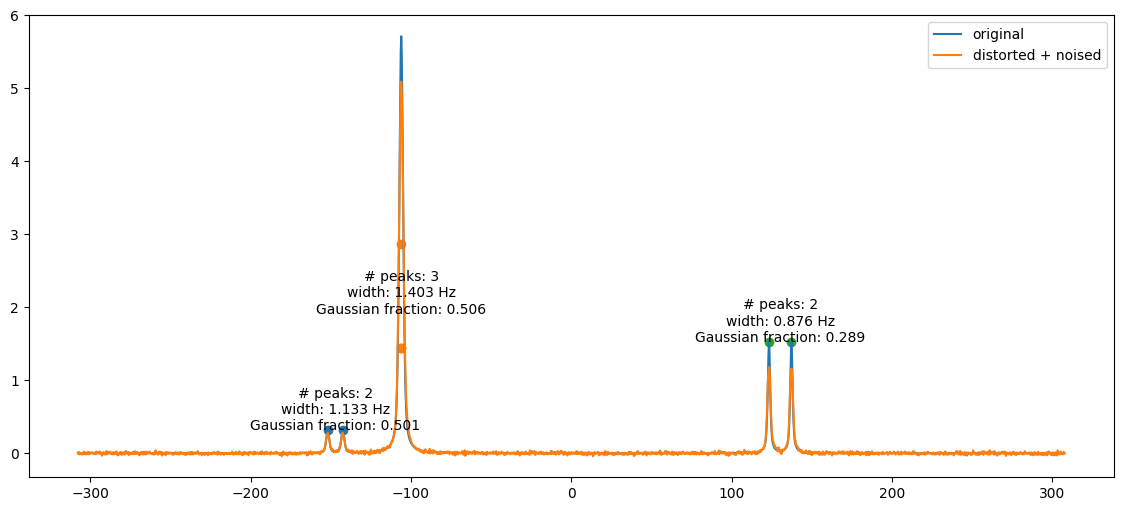

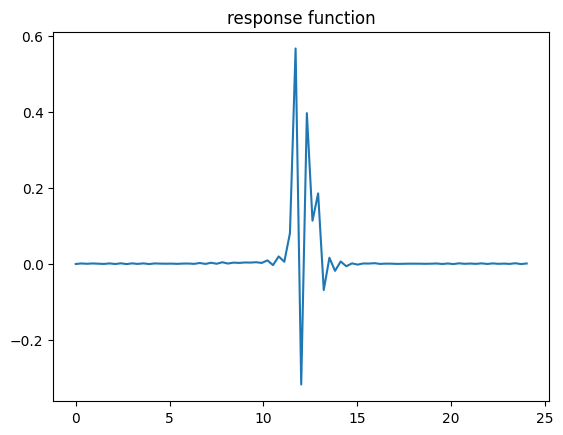

In [60]:
spectrum_index = 1
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



## Custom config

We will use only `data` field

In [61]:
# data paths are already modified
yaml_config = """
data:
  response_functions_files:
  # Paste path to your SCRF file here
  # - Can be absolute path
  # - Can be relative to repository root
  - ../data/scrf_81_600MHz.pt
  atom_groups_data_file: ../data/multiplets_10000_parsed.txt
  response_function_stretch_min: 1.0
  response_function_stretch_max: 1.0
  response_function_noise: 0.0
  multiplicity_j1_min: 0.0
  multiplicity_j1_max: 15
  multiplicity_j2_min: 0.0
  multiplicity_j2_max: 15
  number_of_signals_min: 1
  number_of_signals_max: 3
  thf_min: 4.
  thf_max: 4.
  relative_height_min: 1.
  relative_height_max: 1.
  frq_step: 0.30048
  spectrum_noise_max: 0.005
  spectrum_noise_min: 0
  pixels: 512
"""

config = OmegaConf.create(yaml_config)
data_config = config.data

In [63]:
# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

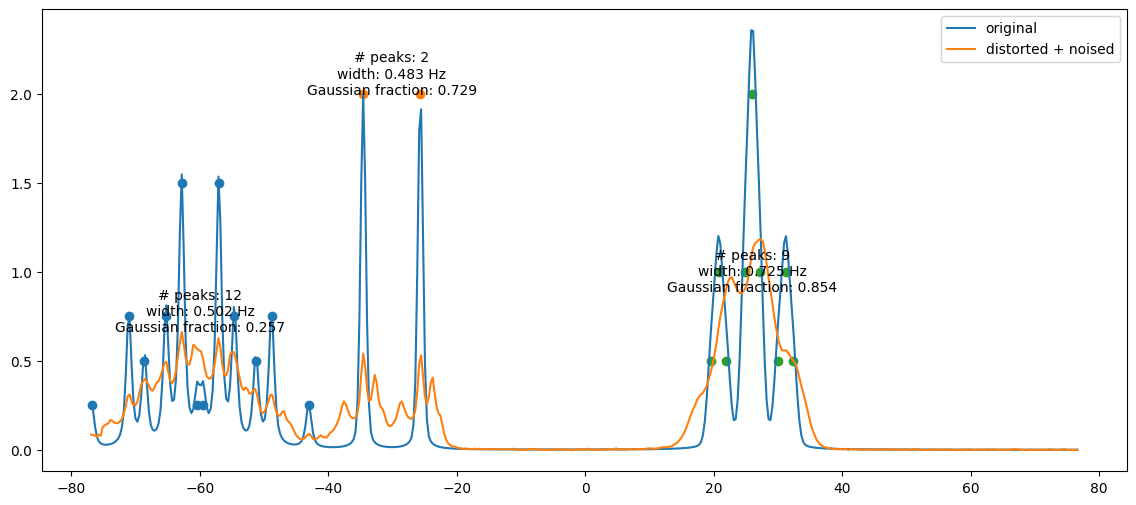

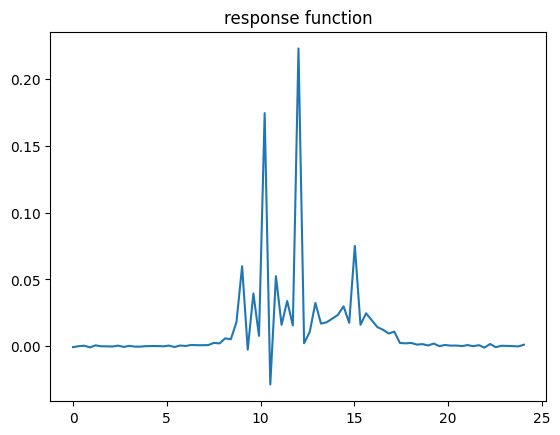

In [64]:
spectrum_index = 1
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



### Other multiplets files

#### singlets

In [72]:
data_config.atom_groups_data_file = "../data/singlets.txt"

# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

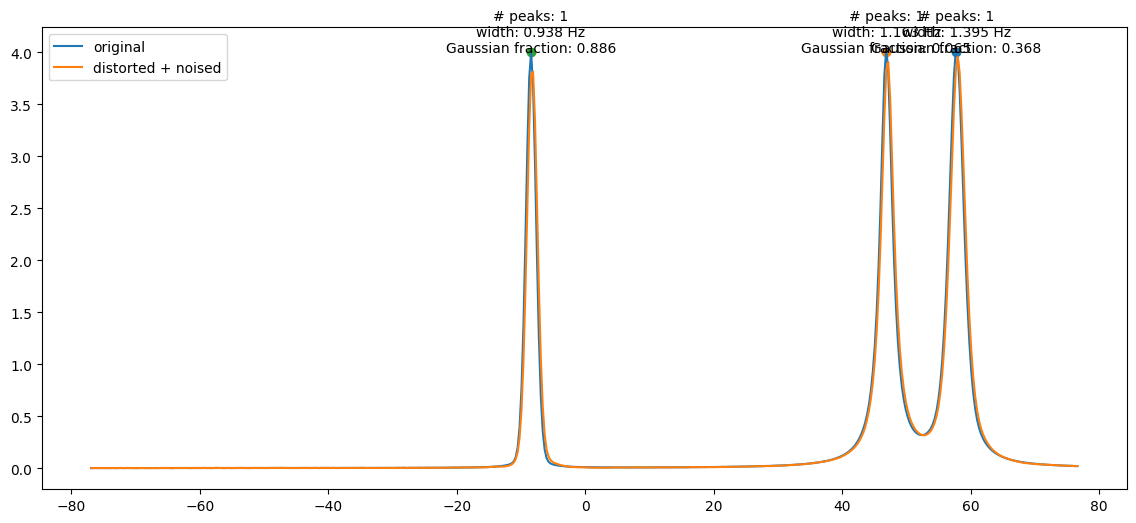

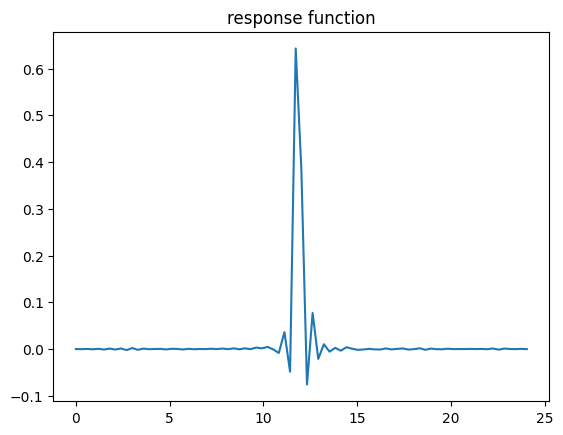

In [74]:
spectrum_index = 0
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



#### doublets

In [78]:
data_config.atom_groups_data_file = "../data/singlets_doublets_triplets.txt"

# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

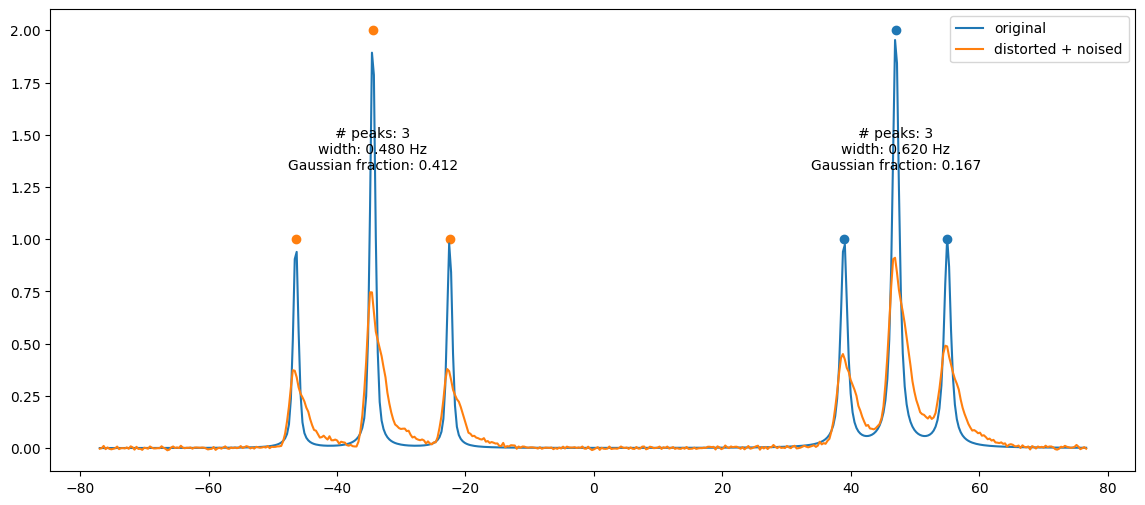

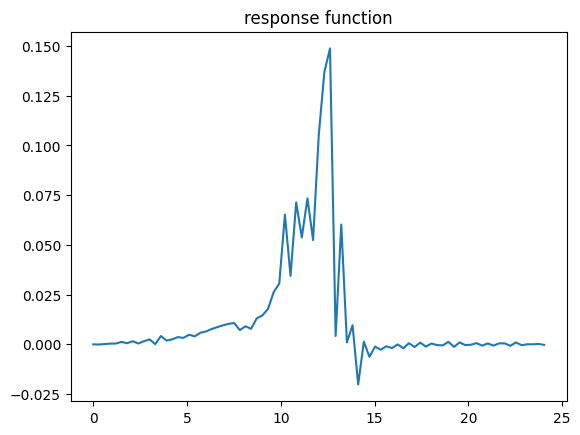

In [79]:
spectrum_index = 0
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")

